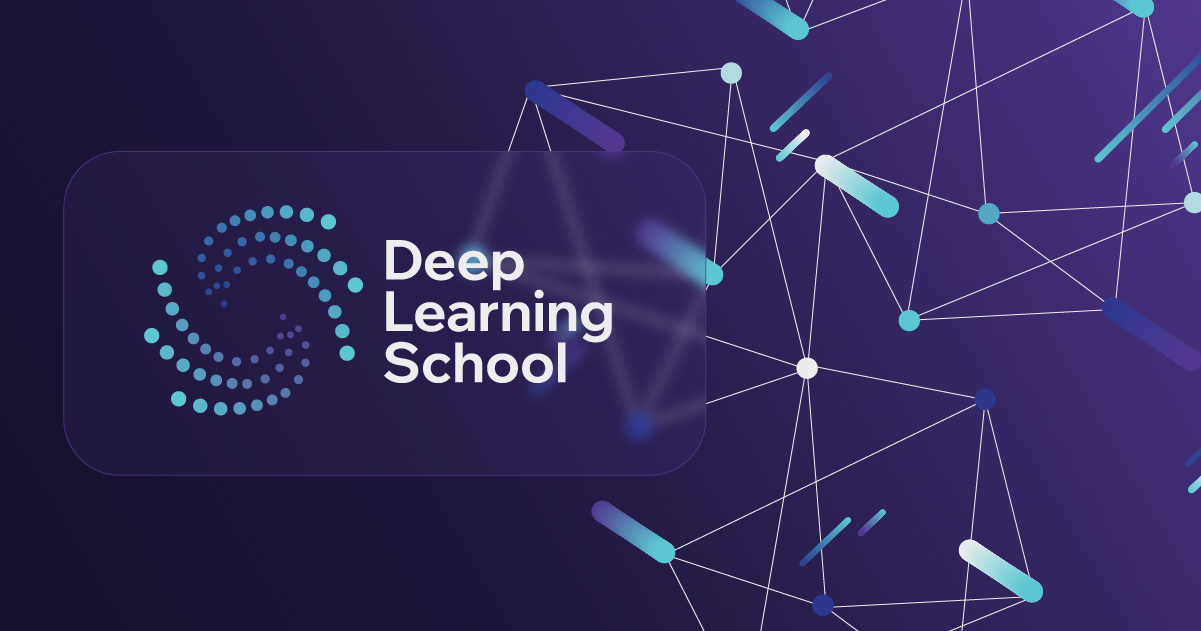

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h1 style="text-align: center;"><b>Домашнее задание. Библиотека sklearn и классификация с помощью KNN</b></h1>

## Описание домашнего задания

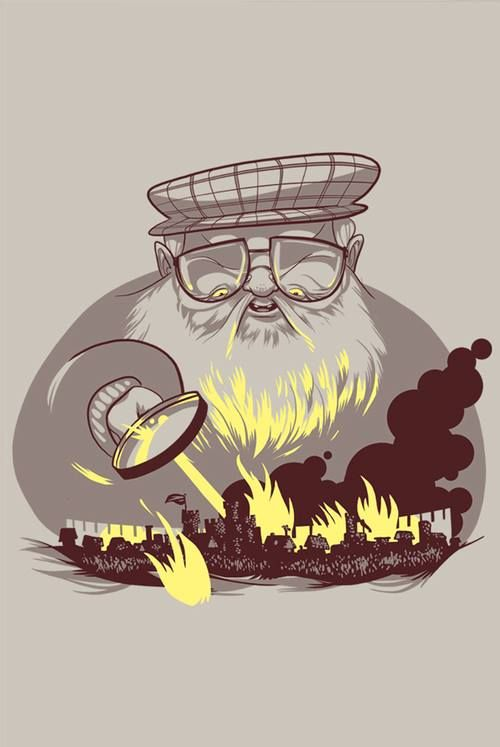

В данном задании вы будете работать с датасетом о персонажах из вселенной Игры Престолов [A Wiki of Ice and Fire](http://awoiaf.westeros.org/). Вам предстоит предсказать, кто из персонажей умрет, а кто останется вживых.



Описание данных:

* **name**: Имя персонажа

* **Title**: Социальный статус или знатность

* **House**: Дом, к которому принадлежит персонаж

* **Culture**: Социальная группа, к которой принадлежит персонаж

* **book1/2/3/4/5**: Появление персонажа в книге

* **Is noble**: Знатность персонажа, основанное на титуле

* **Age**: Отсчет времени: 305 AC

* **male**: Мужчина или женщина

* **dateOfBirth**: дата рождения

* **Spouse**: Имя супруги\а персонажа

* **Father**: Имя отца персонажа

* **Mother**: Имя матери персонажа

* **Heir**: Имя наследника персонажа

* **Is married**: Represents whether the character is married

* **Is spouse alive**: Represents whether character's spouse is alive

* **Is mother alive:** Жива ли мать персонажа

* **Is heir alive:** Жив ли наследник персонажа

* **Is father alive:** Указывает, жив ли отец персонажа

* **Number dead relations:** Количество умерших персонажей, с которыми персонаж связан

* **Popularity score:** Количество внутренних входящих и исходящих ссылок на страницу персонажей в вики http://awoiaf.westeros.org

Целевая переменная:
* **isAlive**: жив ли персонаж в книге

Оценивание:

Баллы считаются следующим образом:

1) $1.00 \geqslant score \geqslant 0.65$ --- 5 баллов

2) $0.65 > score \geqslant 0.50$ --- 4 балла

3) $0.50 > score \geqslant 0.45$ --- 3 балла

4) $0.45 > score \geqslant 0.40$ --- 2 балла

5) $0.40 > score \geqslant 0.35$ --- 1 балл

6) $0.35 > score$ --- 0 баллов

## Часть 1. Анализ и предобработка данных

Здесь вам необходимо сделать все шаги, которые обсуждались в первой части семинара.
* Предобработка данных
  * Обработка пропущенных данных
  * Создание новых признаков
  * Удаление ненужных столбцов
* Анализ данных
  * Анализ целевой переменной
  * Анализ признаков
  * Анализ влияния признаков на целевую переменную
* Подготовка данных для обучения модели

Загружаем датасет

In [1]:
!gdown 1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3 # test dataset
!gdown 1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v # train dataset

Downloading...
From: https://drive.google.com/uc?id=1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3
To: /content/game_of_thrones_test.csv
100% 37.3k/37.3k [00:00<00:00, 92.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v
To: /content/game_of_thrones_train.csv
100% 138k/138k [00:00<00:00, 38.4MB/s]


**Задание 1.1.** Импортируйте библиотеки pandas, matplotlib, seaborn

In [2]:
import pandas as pd
import matplotlib as plt
import seaborn as sns
import numpy as np


**Задание 1.2.** Загрузите датасет в Pandas DataFrame при помощи функции `read_csv`. Вместо дефолтных наименований строк `0,1,...`, при помощи параметра `index_col`, сделайте значения колонки `S.No` наименованиями строк:

In [3]:
# Грузим два датасета, раз их нам заботливо разделили, хотя это означает, что мне придется отдельно обрабатывать тестовый и обучающий датасеты. Не очень удобно.
# Разумно было бы объединить их воедино, затем подготовить, затем разделить. Но чтобы уложиться в автоматическую проверку, я должен буду сделать предсказание для исходной тестовой,
#  а у меня к этому моменту в обучающей точно какие-то данные оттуда будут, что неправильно идеологически.

# Ок, для начала проверю, вдруг тестовая заботливо подготовлена, и ничего с ней не нужно делать.
train_data = pd.read_csv('game_of_thrones_train.csv', index_col="S.No")
test_data = pd.read_csv('game_of_thrones_test.csv', index_col="S.No")

In [4]:
test_data.columns


Index(['name', 'title', 'male', 'culture', 'dateOfBirth', 'mother', 'father',
       'heir', 'house', 'spouse', 'book1', 'book2', 'book3', 'book4', 'book5',
       'isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse',
       'isMarried', 'isNoble', 'age', 'numDeadRelations', 'popularity'],
      dtype='object')

In [5]:
train_data.columns

Index(['name', 'title', 'male', 'culture', 'dateOfBirth', 'mother', 'father',
       'heir', 'house', 'spouse', 'book1', 'book2', 'book3', 'book4', 'book5',
       'isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse',
       'isMarried', 'isNoble', 'age', 'numDeadRelations', 'popularity',
       'isAlive'],
      dtype='object')

Да не похоже, что тестовая выборка подготовлена. Зато я теперь знаю, что в тестовой выборке нет целевой переменной, а значит, я смогу спокойно объединить выборки, обработать вместе, а затем по этому признаку их разделить.

In [6]:
data = pd.concat([test_data, train_data], axis=0, ignore_index=False)

In [7]:
# Проверю, что оно нормально склеилось.

print(f'размерность data {data.shape}')
print(f'размерность train {train_data.shape}')
print(f'размерность test {test_data.shape}')
print(f'количество уникальных значений индекса в data {data.index.nunique()}')

размерность data (1946, 25)
размерность train (1557, 25)
размерность test (389, 24)
количество уникальных значений индекса в data 1946


In [8]:
data.sample(5)
# С количеством строк все в порядке. И даже индекс без повторов, а еще и Наны прописались в колонке IsAlive для тестовой выборки самостоятельно. Отлично.

,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,isAliveMother,isAliveFather,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,popularity,isAlive
S.No,,,,,,,,,,,,,,,,,,,,,
1568,Minisa Whent,Riverrun,0,Rivermen,NaN,NaN,NaN,NaN,House Whent,Hoster Tully,...,NaN,NaN,NaN,0.0,1,1,NaN,0,0.043478,NaN
1775,Morros Slynt,Lord,1,NaN,NaN,NaN,NaN,NaN,House Slynt,NaN,...,NaN,NaN,NaN,NaN,0,1,NaN,0,0.043478,NaN
825,Orbelo,NaN,1,Braavosi,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0,0,NaN,0,0.013378,1.0
1777,Nettles,NaN,0,NaN,113.0,NaN,NaN,NaN,Blacks,NaN,...,NaN,NaN,NaN,NaN,0,0,100.0,0,0.063545,NaN
1278,Otho Bracken,Ser,1,NaN,NaN,NaN,NaN,NaN,House Bracken,NaN,...,NaN,NaN,NaN,NaN,0,1,NaN,0,0.026756,1.0


Посмотрите, какие типы данных представлены в нашем датасете

Знакомый нам метод describe() возвращает различную информацию для столбцов с числовыми типами данных, и с типами данных *object*

Давайте посмотрим на вывод для типа данных *object*. Для этого:
- сначала применим метод describe(). Укажем в качестве аргумента тип данных столбцов, статистику по которым мы хотим посмотреть (см. https://pandas.pydata.org/docs/reference/api/pandas.Series.map.html)
- для удобства восприятия транспонируем таблицу

In [9]:
data.describe(include = 'object').T

,count,unique,top,freq
name,1946,1946,Melara Hetherspoon,1
title,938,262,Ser,384
culture,677,64,Northmen,124
mother,21,17,Daenaera Velaryon,2
father,26,20,Quellon Greyjoy,2
heir,23,22,Jaehaerys Targaryen,2
house,1519,347,Night's Watch,105
spouse,276,254,Walder Frey,7


Теперь давайте посмотрим на столбцы с числовыми типами данных. Дополните код ниже. Для удобства восприятия мы транспонировали таблицу и ограничили вывод тремя столбцами - количество строк без NaN, максимальное и минимальное значение (о кастомизации вариантах вывода describe() вы можете почитать в документации по ссылке выше).


In [10]:
# Поскольку я забыл, как правильно называются типы переменных, то сначала выведу все типы наших столбцов
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1946 entries, 1558 to 1557
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              1946 non-null   object 
 1   title             938 non-null    object 
 2   male              1946 non-null   int64  
 3   culture           677 non-null    object 
 4   dateOfBirth       433 non-null    float64
 5   mother            21 non-null     object 
 6   father            26 non-null     object 
 7   heir              23 non-null     object 
 8   house             1519 non-null   object 
 9   spouse            276 non-null    object 
 10  book1             1946 non-null   int64  
 11  book2             1946 non-null   int64  
 12  book3             1946 non-null   int64  
 13  book4             1946 non-null   int64  
 14  book5             1946 non-null   int64  
 15  isAliveMother     21 non-null     float64
 16  isAliveFather     26 non-null     float64
 1

In [11]:
data.describe(include = [float, int]).T[['count', 'min', 'max']]

,count,min,max
male,1946.0,0.0,1.0
dateOfBirth,433.0,-28.0,298299.0
book1,1946.0,0.0,1.0
book2,1946.0,0.0,1.0
book3,1946.0,0.0,1.0
book4,1946.0,0.0,1.0
book5,1946.0,0.0,1.0
isAliveMother,21.0,0.0,1.0
isAliveFather,26.0,0.0,1.0
isAliveHeir,23.0,0.0,1.0


Так мы проверим, есть ли в данных неадекватнные значения.   Большинство числовых столбцов - это числа от 0 до 1. Отрицательные значения `dateOfBirth` не являются ошибкой. Значения age и `numDeadRelations` также выглядят адекватными. Можно переходить к дальнейшим шагам анализа (анонс - а в тестовых данных нас будет ждать сюрприз).

А, таки авторы подразумевали, что я сначала обаботаю только обучающаю выборку.
Поэтому тут у меня вопросы. Есть какая-то отрицательная шляпа в возрасте. Возможно, отрицательные значения даты рождения это "до начала какой-то эпохи". Но, честно говоря, возиться с признаками, у которых доступно всего около 25% данных от всех строк, звучит как пустая трата времени. Я эти признаки все равно удалю при первичном прогоне так уж точно.

**Задание 1.3.** Предобработка (очистка) данных.

В нашем домашнем задании все пропуски в данных (missing values) уже закодированы как NaN. Проанализируйте, в каких колонках и как часто встречаются NaN значения. Далее вам надо будет принять решение, как их обрабатывать.

In [12]:
data.isna().sum()

,0
name,0
title,1008
male,0
culture,1269
dateOfBirth,1513
mother,1925
father,1920
heir,1923
house,427
spouse,1670


В этом задании удалять строки с NaN (dropna) мы не будем по следующим причинам:
- в обучающем датасете много признаков с большим количество пропусков. Если удалять все строки с NaN, то размер выборки сильно уменьшится. Мы потеряем много данных, которые можно было бы использовать для построения более точной модели.
- тестовом датасете также много признаков с NaN (вы можете в этом убедиться, если скачаете датасет и совершите с ним те же действия, что выше проделали с обучаюшим датасетом). Поэтому нам все-равно придется придумать способ кодировать NaN, чтобы модель делала прогнозы для всех персонажей из тестового датасета. Для этого нам потребуется сохранять, а не удалять данные в обучающем датасете.     



In [13]:
# Ну так и не надо строки, надо признаки-столбцы удалять к такой-то матери.
# Хотя, например, титул может иметь значение, причем в таком количестве (где-то половина от всех наблюдений) может быть будет закономерность не только 1\0, но и некая дифференциация в зависимости от качества этого титула.
# Ладно, пока едем по рельсам задания.

Как вы могли заметить, в наших данных очень много пропущенных значений, причём в некоторых случая пропущена **большая** часть значений. Поэтому заполнять по умолчанию медианой/средним/модой в данном случае - не самый лучший способ (однако, это довольно часто используемый метод заполнения, который может пригодиться вам в будущем)

Ниже мы посмотрим, как можно работать с признаками с большим количеством пропущенных значений.

**Задание 1.4.** Числовые признаки

У нас есть **признак popularity**. Постройте гистограмму распределения данного признака с количеством интервалов (bins), равным 50 (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.hist.html)

<Axes: xlabel='popularity', ylabel='Count'>

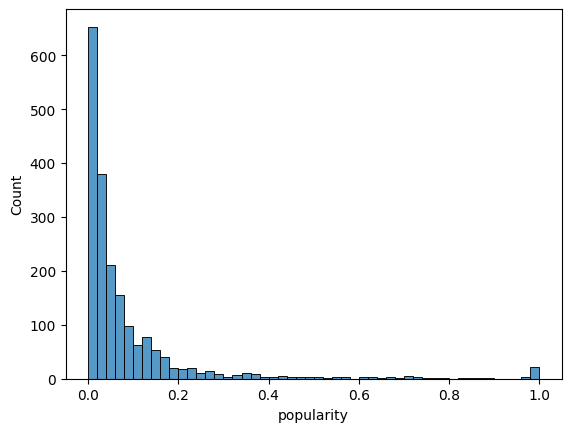

In [14]:
sns.histplot(
    data['popularity'], bins=50
)
# Учитывая, что popularity это количество ссылок на википедии, признак уже предобработан. Возможно, мин-макс скейлером.

Распределение сильно несимметрично. Можно преобразовать данный признак, например, по формуле `np.log10(data["popularity"]*M+1)` (добавляем 1 ради логарифма, так как для некоторых персонажей `popularity==0`). В качестве M можно попробовать, например, M=100 или другое число.

При желании для `popularity` вы можете использовать свой способ шкалирования признаков с несимметричным распределением.


<Axes: xlabel='popularity', ylabel='Count'>

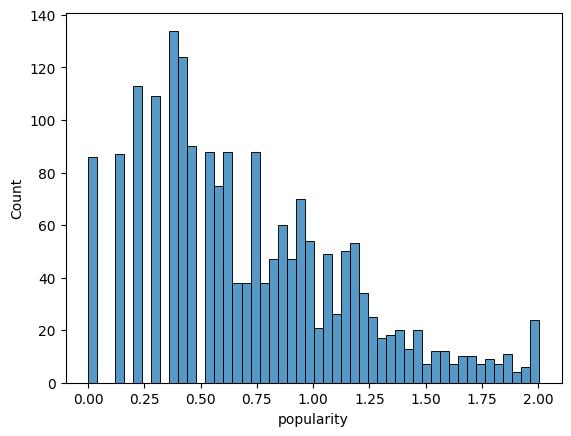

In [15]:
sns.histplot(
    np.log10(data['popularity']*100 +1), bins=50
)

В качестве альтернативного подхода вы можете попробовать дискретизацию признака popularity на основе квантилей (quantile binning), используя функцию qcut() (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.qcut.html). В этом случае вы преобразуете числовой признак popularity в категориальный, для которого в дальнейшем надо будет применить one-hot кодирование.

Теперь давайте обработаем **признак numDeadRelations**.
Посмотрите на частотное распределение этого признака. Лишь для малого числа персонажей `numDeadRelations>0`.

Создайте признак `boolDeadRelations`. Давайте упростим признак `numDeadRelations`, и просто поделим людей на тех, у кого были хоть какие то отношения с мертвыми персонажами, т.е. `numDeadRelations > 0`, и те, у которых не было, т.е. `numDeadRelations = 0`.

In [16]:
# Смотрю
data.numDeadRelations.value_counts()
# Ну, как скажете, упростим. Хотя как будто это может иметь значение.

,count
numDeadRelations,
0,1801
1,49
5,25
4,18
2,12
7,10
6,8
8,5
10,5


In [17]:
# Вспоминаю лямбда функции.
# И справедливо будет дропнуть исходный столбец.
data['boolDeadRelations'] = data.numDeadRelations.apply(lambda x: 1 if x > 0 else 0)

In [18]:
data.drop('numDeadRelations', axis=1, inplace=True)

In [19]:
# Проверка
data.boolDeadRelations.value_counts()

,count
boolDeadRelations,
0,1801
1,145


Наконец, давайте посмотрим на **признак age**. В нем очень много пропущенных значений. Для того, чтобы использовать в модели информацию о возрасте персонажа, мы создадим два новых признака: `age_value` и `age_no_data`

- Там где возраст указан, age_value принимает значение `age`, а `age_no_data` - значение 0.
- Там где возраст не указан, `age_value` принимает значение 0, а `age_no_data` - значение 1.  

Фактически, в переменной `age` мы заменяем NaN на 0, но одновременно добавляем в модель еще один бинарный признак `age_no_data`, несущий информацию о том, у каких персонажей не был указан возраст:        

In [20]:
data['age_value'] = data.age.apply(lambda x: 0 if np.isnan(x) else x)
# Оказывается есть готовая функция для этого мероприятия
# data['age_value'] = data['age'].fillna(0)
data['age_no_data'] = [1 if np.isnan(x) else 0 for x in data['age']]

Этот способ чем-то похож на работу с категориальной переменными с пропущенными значениями, когда мы добавляем еще одну категорию no_data и заменяем NaN на значение этой категории.

Если вы заходите похожим образом образом обработать признак `dateOfBirth`, **обратите внимание**, что у одних и тех же персонажей не указан и возраст, и год рождения.
То есть созданные признаки `age_no_data` и `dateOfBirth_no_data` будут полностью совпадать, и в модель надо будет включать только один из признаков: или `age_no_data`, или `dateOfBirth_no_data`.

**Задание 1.5.** Категориальные признаки с большим количеством категорий

**Признак culture** содержит информацию о принадлежности к одному из народов во вселенной Игры Престолов.

Давайте посмотрим, какие значения принимает данный признак. По умолчанию метод `value_counts()` игнорирует пропуски в данных, поэтому используем этот метод с параметром **dropna** со значением **False** (см. https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.value_counts.html)

<Axes: xlabel='count', ylabel='Count'>

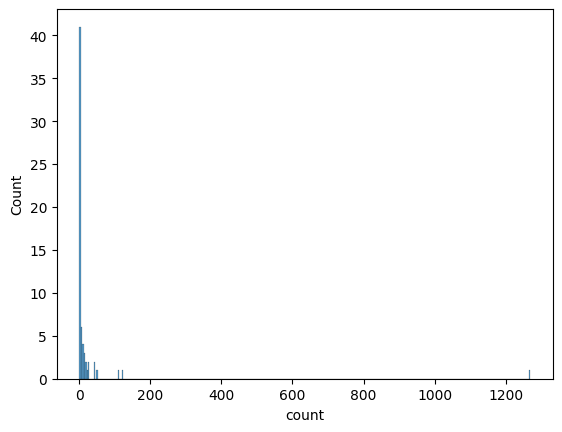

In [21]:
sns.histplot(data['culture'].value_counts(dropna=False))


In [22]:
data['culture'].value_counts(dropna=False)

,count
culture,
NaN,1269
Northmen,124
Ironborn,112
Free Folk,51
Valyrian,43
...,...
Andals,1
Vale,1
free folk,1


Из полученного частотного распределения видно, что для большого числа персонажей значения данного признака не указаны. Также есть много редких значений признака, которые в выборке повторяются один или несколько раз. Причина отчасти в том, что один и тот же народ упоминается в нашем датасете под разными названиями.

Данную проблему мы попытаемся решить, сгруппировав народы в более крупные категории. Так мы одновременно решим проблему того, что один и тот же народ назван в выборке разными способами.

Предоженный вариант группировки имеет определенную логику. Выделяются следующие группы:
- старые нации, которые уже не сущевали как отдельные народы на момент повествования основной линии повествования романов, но отдельные потомки могли еще быть живы
- народы, проживающие в королевствах континента Весторос (для каждого королевства - своя группа)
- народы континента Эссос
- прочие народы

In [23]:
cultures_grouped = {
    'Old Nations': ['valyrian', 'first men', 'andal', 'andals', 'rhoynar'],
    'the North': ['northmen', 'northern mountain clans', 'crannogmen'],
    'the Iron Islands': ['ironborn', 'ironborn', 'ironmen'],
    'the Mountain and the Vale': ['valemen', 'vale', 'vale mountain clans',
                              'sistermen'],
    'the Isles and Rivers': ['riverlands', 'rivermen'],
    'the Rock': ['westerman', 'westermen', 'westerlands'],
    'the Stormlands': ['stormlander', 'stormlands'],
    'the Reach': ['reach', 'reachmen', 'the reach'],
    'Dorne': ['dornish', 'dornishmen', 'dorne'],
    'Essos Nations': ['astapor', 'astapori', 'braavosi', 'braavos', 'tyroshi', 'lysene', 'lyseni',
                      'myrish', 'pentoshi', 'qartheen', 'qarth', 'dothraki',
                      'lhazarene', 'lhazareen','meereen', 'meereenese',
                      'norvoshi', 'qohor', 'summer isles', 'summer islands',
                      'summer islander', 'asshai', "asshai'i", 'norvos', 'ghiscari',
                      'ghiscaricari'],
    'Other Nations': ['ibbenese', 'westeros', 'free folk', 'wildling', 'wildlings', 'naathi']}

**Обратите внимание, что некоторые варианты названий народов встречаются только в тестовых данных, и не встречаются в обучающих данных.** Такая ситуация нередко случается на практике. Поэтому, после обработки обучающих данных и обучения модели важно задать для модели правило, как она должна обрабатывать "незнакомые" категории в категориальных признаках. Например, можно относить объекты с "незнакомой" категорией к некоторой существующей категории или указать формулу расчета для "незнакомой" категории.     

Предложенный вам словарь `cultures_grouped` составлен по всем значениям признака `culture`, встречающимся в тренировочном либо в тестовом датасете. Здесь важно, что все укрупненные категории (ключи/keys словаря `cultures_grouped`) представлены в обоих датасетах, а уникальные для тестового датасета названия народов - это отдельные названия народов внутри укрупненных категорий (значения/values словаря). Поэтому, когда вы будете работать с тестовыми - просто применяйте этот словарь без указания правила обработки "незнакомых" категорий.

Давайте приступим к кодировке значений признака culture.
Для этого сначала инвертируем словарь *cultures_grouped*

In [24]:
#Довольно просто инвертировать словарь, где ключу соответствует одно значение
#В нашем случае ключу соответствует список значений.
#Ниже показан пример, как можно инвертировать такой словарь

d = {'A': ['a1', 'a2', 'a3'],
     'B': ['b1', 'b2', 'b3', 'b4']}

d_inverted = {}
for k in d.keys():
  for v in d[k]:
      d_inverted.update({v:k})

d_inverted

{'a1': 'A', 'a2': 'A', 'a3': 'A', 'b1': 'B', 'b2': 'B', 'b3': 'B', 'b4': 'B'}

In [25]:
# По аналогии с примером выше инвертируйте словарь cultures_grouped
cultures_grouped_inverted = {}
for k in cultures_grouped.keys():
  for v in cultures_grouped[k]:
    cultures_grouped_inverted.update({v:k})

In [26]:
cultures_grouped_inverted

{'valyrian': 'Old Nations',
 'first men': 'Old Nations',
 'andal': 'Old Nations',
 'andals': 'Old Nations',
 'rhoynar': 'Old Nations',
 'northmen': 'the North',
 'northern mountain clans': 'the North',
 'crannogmen': 'the North',
 'ironborn': 'the Iron Islands',
 'ironmen': 'the Iron Islands',
 'valemen': 'the Mountain and the Vale',
 'vale': 'the Mountain and the Vale',
 'vale mountain clans': 'the Mountain and the Vale',
 'sistermen': 'the Mountain and the Vale',
 'riverlands': 'the Isles and Rivers',
 'rivermen': 'the Isles and Rivers',
 'westerman': 'the Rock',
 'westermen': 'the Rock',
 'westerlands': 'the Rock',
 'stormlander': 'the Stormlands',
 'stormlands': 'the Stormlands',
 'reach': 'the Reach',
 'reachmen': 'the Reach',
 'the reach': 'the Reach',
 'dornish': 'Dorne',
 'dornishmen': 'Dorne',
 'dorne': 'Dorne',
 'astapor': 'Essos Nations',
 'astapori': 'Essos Nations',
 'braavosi': 'Essos Nations',
 'braavos': 'Essos Nations',
 'tyroshi': 'Essos Nations',
 'lysene': 'Essos Na

Теперь создадим новый столбец с укрупненными значениями culture.

Для этого будем использовать метод `map()` с инвертированным словарем в качестве аргумента (https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.map.html)

Обратите внимание, что в словаре названия народов указаны в нижнем регистре. А в датасете используется как нижний, так и верхний регистр. Поэтому перед применением метода `map()` переведем значения столбца culture в нижний регистр при помощи метода `str.lower()` (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.str.lower.html).

In [27]:
data['culture_grouped'] = data['culture'].str.lower().map(cultures_grouped_inverted)

Осталось заменить все NaN в созданном столбце на категорию `culture_no_data`:

In [28]:
data['culture_grouped'].fillna('culture_no_data', inplace=True)

/tmp/ipykernel_7868/223294471.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['culture_grouped'].fillna('culture_no_data', inplace=True)


<Axes: xlabel='count', ylabel='Count'>

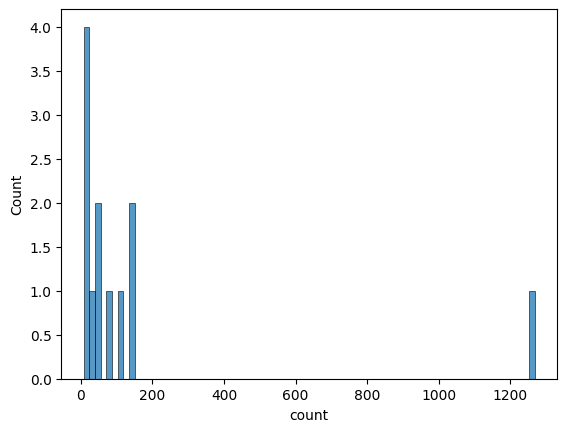

In [29]:
sns.histplot(data['culture_grouped'].value_counts(), bins = 80)

Распределение сгруппированной переменной выглядит гораздо лучше. Но по прежнему есть несколько слабо представленых групп.

Дальнейшую работу с этим признаком проводите на свое усмотрение для повышения качества прогноза модели. Например, можно объединить несколько слабо представленных категорий в одну или применить другой подход.

**Задание 1.6.** Категориальные признаки в линейных моделях

Для включения категориальных признаков в линейную модель их нужно преобразовать в числовые признаки.

Если признак принимает одно из двух возможных значений (например, персонаж "появляется" или "не появляется" в 1-й книге), он напрямую кодируется в бинарный признак ("появляется" -> 1, "не появляется" -> 0). Если признак принимает больше двух значений, его можно преобразовать в несколько бинарных при помощи one-hot преобразования. В некоторых случаях бывает полезно объединить некоторые категории, как мы это поступили с признаком *culture*.

Порядковых признаков у нас в задаче нет, поэтому рассматривать их здесь мы не будем.

Для того, чтобы найти все порядковые (видимо, авторы имеют ввиду категориальные, только что написали, что порядковых у нас нет) признаки, посмотрим на количество уникальных значений, которые встречаются в столбцах. Для столбцов с типом object количество уникальных значений мы выводили  при помощи метода `describe()` в задании 1.2.

Чтобы посмотреть количество уникальных значений для всех столбцов, можно воспользоваться методом nunique() (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.nunique.html)

In [30]:
# Количество уникальнх значений в каждом столбце
data.nunique()

,0
name,1946
title,262
male,2
culture,64
dateOfBirth,134
mother,17
father,20
heir,22
house,347
spouse,254


In [31]:
# Для числовых столбцов можно вывести в одну таблицу более детальную статистику, объединив выводы describe() и nunique()
# Код ниже требуется дополнить по аналогии с заданием 1.2.
data.describe(include = [float, int]).T[['count', 'min', 'max']].assign(N_unique_values = data.nunique())

,count,min,max,N_unique_values
male,1946.0,0.0,1.0,2
dateOfBirth,433.0,-28.0,298299.0,134
book1,1946.0,0.0,1.0,2
book2,1946.0,0.0,1.0,2
book3,1946.0,0.0,1.0,2
book4,1946.0,0.0,1.0,2
book5,1946.0,0.0,1.0,2
isAliveMother,21.0,0.0,1.0,2
isAliveFather,26.0,0.0,1.0,2
isAliveHeir,23.0,0.0,1.0,2


Посмотрев на количество уникальных значений мы можем выделить категориальные признаки. Например, `popularity` принимает значения от 0 до 1, но это непрерывный числовой признак. Остальные признаки со значениями от 0 до 1 - принимают только два значения, то есть являются бинарными.

Бинарные признаки без NaN полностью готовы для включения в модель. Некоторые бинарные признаки содержат пропуски, поэтому, если вы захотите включить их в модель, их потребуется обработать.

Для бинарных признаков их связь с зависимой переменной можно прикинуть по таблице корреляций. Для категориальных признаков с количеством значений больше двух (или с двумя значениями и NaN) можно сделать one-hot преобразования и посчитать корреряцию зависимой переменной с набором сгенерированных бинарных признаков.
В качестве альтернативного подхода можно использовать сравнение средних значений зависимой переменной для разных категорий исследуемого признака. Чем сильнее различаются средние значения целевой переменной между категориями, тем вероятнее, что данный признак связан с зависимой переменной.

In [32]:
# попробуйте провести сравнение средних зависимой пременной isAlive для признака isAliveSpouse
# одним из приведенных ниже способов:
# Помним, что я-то умный, я объединил оба дф, и у меня в isAlive есть Nan. Поэтому иду курить, как они влияют на эту группировку и вычисление среднего.
# Итак, Nan  в группирующем столбце - тут это isAliveSpouse учитываются из-за  dropna = False, что я и вижу. А вот mean(), применяемое к isAlive по умолчанию игнорирует наны.
# Т.е, хотя у меня включены строки с Нанами в ЯЖив, но среднее считается без них. Круть.

data.groupby('isAliveSpouse', dropna = False)['isAlive'].mean()
# pd.pivot_table(data = data, values = 'isAlive', index = 'НАЗВАНИЕ ПРИЗНАКА', aggfunc=['mean', 'count'], dropna=False)

,isAlive
isAliveSpouse,
0.0,0.619048
1.0,0.753165
NaN,0.786293


In [33]:
# Но это не корреляция, это просто средние значения.
# Попробую смастрячить корреляцию
# Это базовый Пирсон. И как будто это негодная корреляция для бинарных признаков. Хотя, была бы она годной, мы бы сказали, что корреляции нет.
print(data['isAliveSpouse'].corr(data['isAlive']))

0.12234084395466265


In [34]:
# Так, ладно, серьезная статистика сложная. С кондачка не разберусь.
# Дипсик предлагает в том числе отношение шансов, и его статистическую оценку
contingency_table = pd.crosstab(data['isAliveSpouse'], data['isAlive'])
from scipy.stats import fisher_exact

odds_ratio, p_value = fisher_exact(contingency_table)
print(f'odds_ratio = {odds_ratio}, p_value_fisher = {p_value}')

odds_ratio = 1.8777120315581854, p_value_fisher = 0.1185779717685449


И вывод тут, видимо, такой:
1.9 это во столько раз вероятность быть живым, если твой супруг жив, больше. Но! надо учитывать, что crosstab проигнорировал ВСЕ наны, в обеих колонках.
Насчет пи-в. Тут отдельная заморочка. Идейно правильно вывод будет звучать как-то так: Данные нашей выборки скорее согласуются с нулевой гипотезой (подобное отношение шансов случайно).

In [35]:
# дипсик пишет, что точный тест фишера скорее для малых выборок, а для больших хи квадрат. Это, конечно, не аргументация и сильное упрощение, но просто ради интереса посмотрю.
from scipy.stats import chi2_contingency
chi2, p_value_chi, dof, expected = chi2_contingency(contingency_table)

print(f"Статистика хи-квадрат: {chi2}")
print(f"p-value: {p_value_chi}")

# Принципиально не отличается.

Статистика хи-квадрат: 2.3585609792506346
p-value: 0.12459707755761075


In [36]:
# Итак, все-таки я удалю признаки с большим количеством пропусков. Назову try1_data
# Поскольку пропуски дают единичку, то численно среднее будет эквивалентно доле нанов
# ну давай для начала уберу все, что больше 80% пропусков имеет. Сразу не получается так отфильтровать, потому что isnamean выдает булеву маску, с длинной равной количеству колонок
# И мы ее прикладываем к объекту "индекс", типа список колонок, той же длинны, что важно.
columns_to_keep = data.columns[data.isna().mean() <0.8].tolist()
try1_data = data[columns_to_keep].copy()
try1_data.isna().mean()
# Фига, работает.
# Title я как-нибудь обработаю, в конце концов отстутсиве титула это норма, это реальные данные.
#  Culture оставлю, раз уж мы с ней поработали.
# Age и dateofbirth имеют говоряще одинаковое количество пропусков, и наверняка 100% скоррелированы. Все равно я их обе удалю пока. Но проверю, что они скоррелированы, и, если бы они не были такими пустыми, то я бы оставил одну
# из этих колонок, либо как-то из них двух сделал новый признак.

,0
name,0.000000
title,0.517986
male,0.000000
culture,0.652107
dateOfBirth,0.777492
house,0.219424
book1,0.000000
book2,0.000000
book3,0.000000
book4,0.000000


# Проверка корреляции dateOfBirth и age

<Axes: xlabel='dateOfBirth', ylabel='Count'>

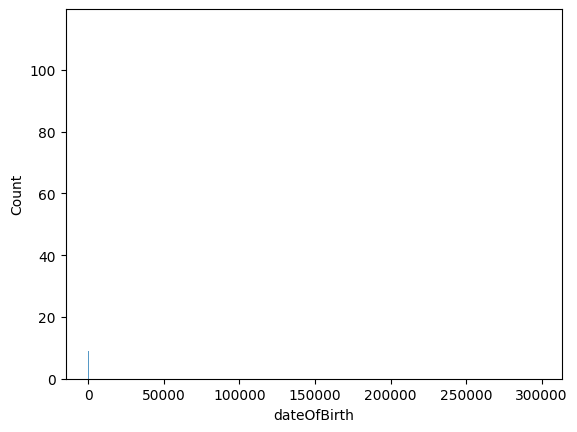

In [37]:
# Проверка корреляции dateOfBirth и age
sns.histplot(try1_data['dateOfBirth'])

In [38]:
try1_data[['age', 'dateOfBirth']].describe()

,age,dateOfBirth
count,433.000000,433.000000
mean,-1293.563510,1577.364896
std,19564.340993,19565.414460
min,-298001.000000,-28.000000
25%,18.000000,240.000000
50%,27.000000,268.000000
75%,50.000000,285.000000
max,100.000000,298299.000000


<Axes: ylabel='dateOfBirth'>

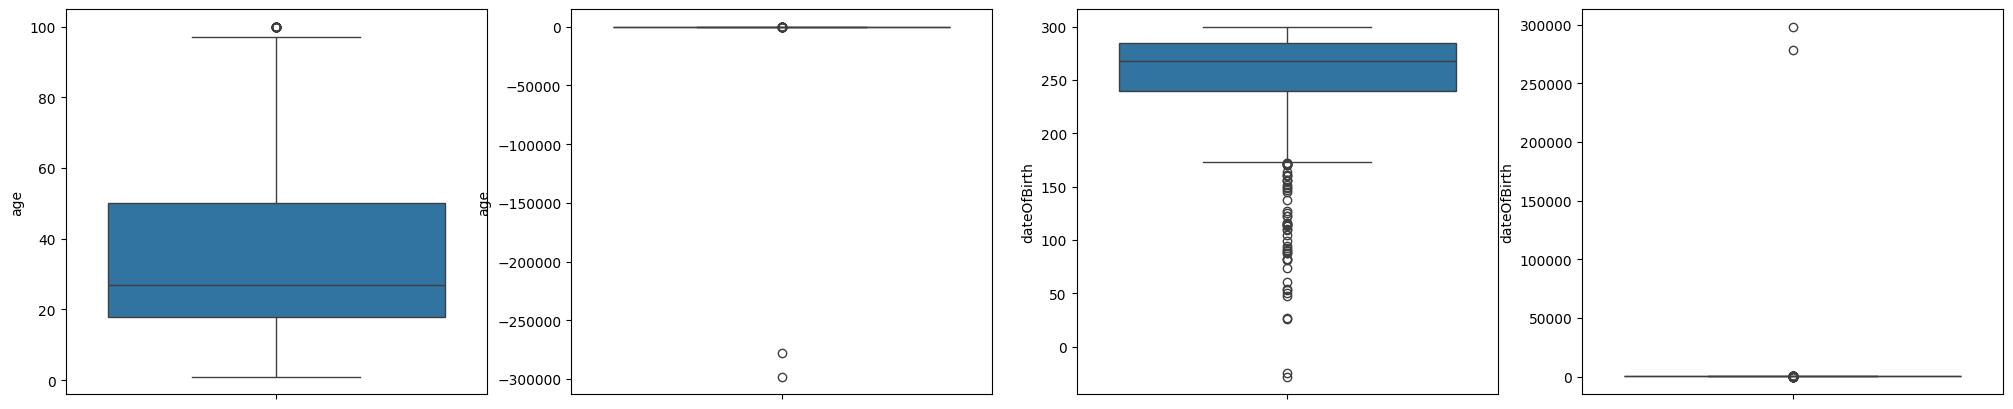

In [39]:
# С датой рождения ничего не сделаем, хз как они там считают эти даты, надо в них углубляться. А помним, что я все равно оба столбца удалю в этом прогоне, и делаю этот анализ только из соображений тренировки.
# А вот возраст явно имеет какой-то выброс, может несколько. Который просто нужно удалить. Боксплот пробую. Нарисую два - с фильтрацией и без
plt.pyplot.figure(figsize=(25, 5))
plt.pyplot.subplot(1, 4, 1)
sns.boxplot(try1_data.age[try1_data.age > 0])

plt.pyplot.subplot(1, 4, 2)
sns.boxplot(try1_data.age)

plt.pyplot.subplot(1, 4, 3)
sns.boxplot(try1_data.dateOfBirth[try1_data.dateOfBirth < 50000])

plt.pyplot.subplot(1, 4, 4)
sns.boxplot(try1_data.dateOfBirth)
# Ну и норм, когда пару явный косяков отрицательных убираешь.

In [40]:
# Ну что, возраст это нормально распределенная величина? Пирсона опять
# Только я это сделаю на отдельном дф, где не будет нанов, и не будет аномальных значений из этих колонок
data_age_birth_corr = try1_data[['age', 'dateOfBirth']].copy()
data_age_birth_corr.dropna(inplace=True)
data_age_birth_filtred = data_age_birth_corr[(data_age_birth_corr.age > 0) & (data_age_birth_corr.dateOfBirth < 400)]
print(data_age_birth_filtred['age'].corr(data_age_birth_filtred['dateOfBirth']))

-0.541090469895147


In [41]:
# Итак, корреляция какая-то не совсем удовлетворительная. Да, отрицательная - чем меньше дата рождения, тем больше лет персонажу, логично.
# Но при этом она средняя, даже не сильная. И это странно, должна быть -1. Хотяяяя, это ж Мартин. Не факт, что автор заморочился и сопоставил по-честному возраст и даты рождения
# Ну да ладно, все равно убираю обе эти колонки. А заодно и обработанную culture, вместо нее culture_grouped есть
# А еще удаляю, не проверяя колонку title - т.к. сейчас увидел, что уже есть колонка isNoble, что в принципе отражает то, что я хотел сделать с этими титулами.
# А еще удаляю age_value, age_no_data, которые мы создали ранее, забыл про них
try1_data.drop(['age', 'dateOfBirth', 'culture', 'title', 'age_value', 'age_no_data'], axis=1, inplace=True)

In [42]:
try1_data

,name,male,house,book1,book2,book3,book4,book5,isMarried,isNoble,popularity,isAlive,boolDeadRelations,culture_grouped
S.No,,,,,,,,,,,,,,
1558,Melissa Blackwood,0,House Blackwood,0,0,0,0,1,0,0,0.050167,NaN,0,culture_no_data
1559,Melisandre,0,R'hllor,0,1,1,1,1,0,0,0.745819,NaN,0,Essos Nations
1560,Merrit,0,Brotherhood without banners,0,0,1,1,0,0,0,0.010033,NaN,0,culture_no_data
1561,Meryn Trant,1,House Trant,1,1,1,1,1,0,1,0.220736,NaN,0,culture_no_data
1562,Merrett Frey,1,House Frey,1,1,1,1,1,1,0,0.434783,NaN,0,the Isles and Rivers
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1553,Marwyn,1,NaN,1,0,1,1,0,0,1,0.160535,1.0,0,culture_no_data
1554,Masha Heddle,0,NaN,1,1,0,0,0,0,0,0.040134,0.0,0,culture_no_data
1555,Matthos Seaworth,1,House Seaworth,0,1,1,1,1,0,0,0.076923,0.0,0,culture_no_data


In [43]:
# Есть еще колонка имен, которые по идее должны быть естественным образом уже закодированы в нашем индексе по номерам. И уж точно имя само по себе, закодированное от балды в цифру не будет иметь влияния на модель.
# А если и будет, то это еще хуже. Разве что, в именах есть некие криптографические закономерности, оставленные автором - персонажей на заклание называл так, что сумма букв по алфавиту от 30 до 100, например.
# Но это надо искать. мужик_с_безумным_взглядом_и_картой.жипег
# Проверю, что количество уникальных значений в колонке имен равно длине дф.
try1_data.name.nunique() == len(try1_data)

True

In [44]:
# Дропать колонки! Мое любимое.
try1_data.drop(['name'], axis=1, inplace=True)

In [45]:
try1_data
# Ну вот и все. Осталось закодировать Дом, учтя наны, по подобию того, что мы сделали с культурами. И сгруппированные культуры тоже закодировать.

,male,house,book1,book2,book3,book4,book5,isMarried,isNoble,popularity,isAlive,boolDeadRelations,culture_grouped
S.No,,,,,,,,,,,,,
1558,0,House Blackwood,0,0,0,0,1,0,0,0.050167,NaN,0,culture_no_data
1559,0,R'hllor,0,1,1,1,1,0,0,0.745819,NaN,0,Essos Nations
1560,0,Brotherhood without banners,0,0,1,1,0,0,0,0.010033,NaN,0,culture_no_data
1561,1,House Trant,1,1,1,1,1,0,1,0.220736,NaN,0,culture_no_data
1562,1,House Frey,1,1,1,1,1,1,0,0.434783,NaN,0,the Isles and Rivers
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1553,1,NaN,1,0,1,1,0,0,1,0.160535,1.0,0,culture_no_data
1554,0,NaN,1,1,0,0,0,0,0,0.040134,0.0,0,culture_no_data
1555,1,House Seaworth,0,1,1,1,1,0,0,0.076923,0.0,0,culture_no_data


In [46]:
# заменяю наны в домах на house_no_data
try1_data.house.fillna('house_no_data', inplace=True)

/tmp/ipykernel_7868/2711016220.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  try1_data.house.fillna('house_no_data', inplace=True)


In [47]:
# Кодируем! Т.к. для имен и названий домов не определен порядок, и тем более расстояния между ними, то используем One Hot
# А еще дипсик пишет, что классная практика удалить одну из колонок закодированных.
# Мотивирует тем, что если не удалить, тогда появляется проблема мультиколлинеарности - одну колонку можно выразить через остальные. Особенно от нее будут страдать модели на основе регрессии.
try1_onehot = pd.get_dummies(try1_data, columns=['house', 'culture_grouped'], drop_first=True)
try1_onehot
# Караул, 369 колонок... Может быть надо было как-то объединить дома Вестероса...

,male,book1,book2,book3,book4,book5,isMarried,isNoble,popularity,isAlive,...,culture_grouped_Old Nations,culture_grouped_Other Nations,culture_grouped_culture_no_data,culture_grouped_the Iron Islands,culture_grouped_the Isles and Rivers,culture_grouped_the Mountain and the Vale,culture_grouped_the North,culture_grouped_the Reach,culture_grouped_the Rock,culture_grouped_the Stormlands
S.No,,,,,,,,,,,,,,,,,,,,,
1558,0,0,0,0,0,1,0,0,0.050167,NaN,...,False,False,True,False,False,False,False,False,False,False
1559,0,0,1,1,1,1,0,0,0.745819,NaN,...,False,False,False,False,False,False,False,False,False,False
1560,0,0,0,1,1,0,0,0,0.010033,NaN,...,False,False,True,False,False,False,False,False,False,False
1561,1,1,1,1,1,1,0,1,0.220736,NaN,...,False,False,True,False,False,False,False,False,False,False
1562,1,1,1,1,1,1,1,0,0.434783,NaN,...,False,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1553,1,1,0,1,1,0,0,1,0.160535,1.0,...,False,False,True,False,False,False,False,False,False,False
1554,0,1,1,0,0,0,0,0,0.040134,0.0,...,False,False,True,False,False,False,False,False,False,False
1555,1,0,1,1,1,1,0,0,0.076923,0.0,...,False,False,True,False,False,False,False,False,False,False


In [48]:
# Гляну на исходные дома
try1_data.house.value_counts()
# Ладно, пока не буду их объединять в группы, хотя вот эти мелкие...
vc = try1_data.house.value_counts()
rare_houses = vc[vc < 5]
rare_hous_list = rare_houses.index.tolist()
rare_hous_list

# Так, ладно, переделываем. Пусть в группы по смыслу я их и не объединю, но вот выделить группы - типа редкие дома, частые дома могу и сделаю. Надо только отсечки как-то выбрать. Может по квартилям?

["House Baratheon of King's Landing",
 'House Ambrose',
 'House Farring',
 'House Vance',
 'House Hunter',
 'House Goodbrook',
 "House Vance of Wayfarer's Rest",
 'House Darklyn',
 'House Hornwood',
 'House Ironmaker',
 'House Fossoway of Cider Hall',
 'House Corbray',
 'House Manwoody',
 'House Tarth',
 'House Lefford',
 'House Lothston',
 'Happy Port',
 'House Cassel',
 'Blacks',
 'House Farwynd of the Lonely Light',
 'House Strong',
 'House Reed',
 'House Yronwood',
 'House Kettleblack',
 'Kingswood Brotherhood',
 'House Qorgyle',
 'House Morrigen',
 'House Smallwood',
 'House Butterwell',
 'House Sharp',
 'House Bulwer',
 "R'hllor",
 'House Uller',
 'House Grafton',
 'House Staunton',
 'House Costayne',
 'House Stout',
 'House of Galare',
 'House Frey of Riverrun',
 'House Stackspear',
 'House Slynt',
 'House Piper',
 'Moon Brothers',
 'House Vypren',
 'Stormcrows',
 'House Fossoway of New Barrel',
 'House Payne',
 'House Marbrand',
 'House Mooton',
 'House Locke',
 'House Santagar

In [49]:
vc.describe()
# Ну а что я ожидал увидеть в этих квартилях и в самом деле-то.
# Первая квартиль 1, медиана 2
# А, тьфу, я сюда включил наны, которые сиречь неизвестные дома.

,count
count,348.000000
mean,5.591954
std,24.804484
min,1.000000
25%,1.000000
50%,2.000000
75%,4.000000
max,427.000000


In [50]:
# Уот такая хитрость. Я попробовал сначала просто vc[1:], и оно довольно долго выполнялось. Оказывается, срез делается питоном по индексу, а у нас тут индексы - строковые значения.
# В общем, ему тяжко. И может быть еще и ошибется. В таком срезе он ищет по значениям индексов
# А вот с iloc он ищет по позициям!
vc_no_unnknown = vc.iloc[1:]
vc_no_unnknown.describe()
# Штош... принципиально не поменялось ничего. Идея с квартилями не канает.

,count
count,347.000000
mean,4.377522
std,10.114881
min,1.000000
25%,1.000000
50%,2.000000
75%,4.000000
max,105.000000


<BarContainer object of 25 artists>

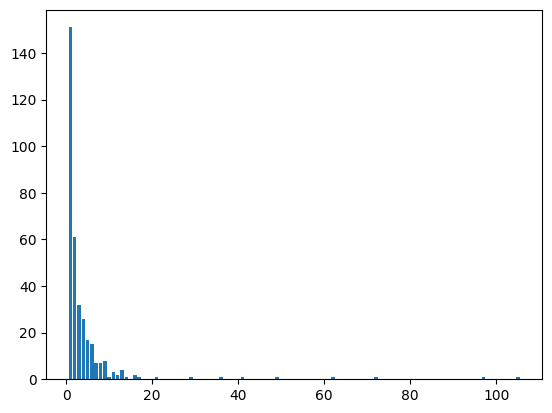

In [51]:
# Так. Мне нужен какой-то график. Типа представленность (процент?) каждого варианта значений value_counts. Т.е. какой процент домов встречается один раз, два раза и т.д.
# Часто встречающиеся не интересны, их я в любом случае оставлю как есть. Но вот вопрос - с какого количества мне объединять дома в одну категорию "мелкопоместные поцы"?
freq_distrib = vc_no_unnknown.value_counts()
plt.pyplot.bar(freq_distrib.index, freq_distrib.values)

In [52]:
# Даже и не знаю, как выбрать. Оооо, кажись вспомнил! Что-то такое было на биоинфе. Там кривулину строили, сравнивая сколько пользы(?) дает увеличение количества признаков(?).
# Хм, или не подойдет с таким "хвостом" из кучи одноразовых домов.
# Окей, а если из житейской логики - дом имеет одного перса - так это значит, что скорее всего в тестовой выборке этого дома не будет, а если будет, то модель слишком уж переобучится на единственном доме в тренировочной,
# и может ошибочно полагать, что есть связь между домом и исходом.
# Правда, это не отвечает на вопрос, а скольких персонажей считать "редким домом"?
# Нельзя ли исходить из статистических соображений о величине выборки? Типа 30 это минимум, с которым приятно работать. Т.е. если бы мы рассматривали только зависимость принадлежности к Дому и выживаемости,
# то хотели бы иметь не меньше 30 персов в доме. Заманчиво.
# О, дипсик меня одобрил, правда внес предложение, раз уж дома это только одна из нескольких переменных, да еще и регерссии имеют более мягкие требования,
#  Поэтому для сохранения разнообразия краснокнижных Домов, понизим планку до 10-15 человеков. Мастерским произволом назначаю 12.

# Итак, поскольку я оставлю для истории исходный try1_onehot, то сделаю новый, но сначала модифицирую колонку с домами согласно принятого решения.
# надо собрать список из таких домов.
rare_houses = vc[vc <= 12].index.tolist()
try1_data['house'] = try1_data['house'] .replace(rare_houses, 'rare_houses')

In [53]:
try1_data['house'].value_counts()
# Ай, красиво!
# Вот теперь кодировать.

,count
house,
rare_houses,892
house_no_data,427
Night's Watch,105
House Frey,97
House Stark,72
House Targaryen,62
House Lannister,49
House Greyjoy,41
House Tyrell,36


In [54]:
try1_onehot_2 = pd.get_dummies(try1_data, columns=['house', 'culture_grouped'], drop_first=True)
try1_onehot_2
# О, 40 колонок, кажется более разумным подходом.

,male,book1,book2,book3,book4,book5,isMarried,isNoble,popularity,isAlive,...,culture_grouped_Old Nations,culture_grouped_Other Nations,culture_grouped_culture_no_data,culture_grouped_the Iron Islands,culture_grouped_the Isles and Rivers,culture_grouped_the Mountain and the Vale,culture_grouped_the North,culture_grouped_the Reach,culture_grouped_the Rock,culture_grouped_the Stormlands
S.No,,,,,,,,,,,,,,,,,,,,,
1558,0,0,0,0,0,1,0,0,0.050167,NaN,...,False,False,True,False,False,False,False,False,False,False
1559,0,0,1,1,1,1,0,0,0.745819,NaN,...,False,False,False,False,False,False,False,False,False,False
1560,0,0,0,1,1,0,0,0,0.010033,NaN,...,False,False,True,False,False,False,False,False,False,False
1561,1,1,1,1,1,1,0,1,0.220736,NaN,...,False,False,True,False,False,False,False,False,False,False
1562,1,1,1,1,1,1,1,0,0.434783,NaN,...,False,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1553,1,1,0,1,1,0,0,1,0.160535,1.0,...,False,False,True,False,False,False,False,False,False,False
1554,0,1,1,0,0,0,0,0,0.040134,0.0,...,False,False,True,False,False,False,False,False,False,False
1555,1,0,1,1,1,1,0,0,0.076923,0.0,...,False,False,True,False,False,False,False,False,False,False


**Задание 1.7.** Проанализируйте признаки.
  * Обработайте категориальные признаки и переведите их в числа. Можете выбрать любой кодировщик. Не забудьте, что потом аналогичным образом вам надо будет преобразовывать тестовый датасет, используя тот же алгоритм кодирования признаков.
  * Проанализируйте количественные признаки. Есть ли корреляция между признаками?

In [55]:
try1_data.info()
# Из количественных у меня осталась только Популярность. Остальные по сути категориальные бинарные.
# Так что нечего коррелировать

<class 'pandas.core.frame.DataFrame'>
Index: 1946 entries, 1558 to 1557
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   male               1946 non-null   int64  
 1   house              1946 non-null   object 
 2   book1              1946 non-null   int64  
 3   book2              1946 non-null   int64  
 4   book3              1946 non-null   int64  
 5   book4              1946 non-null   int64  
 6   book5              1946 non-null   int64  
 7   isMarried          1946 non-null   int64  
 8   isNoble            1946 non-null   int64  
 9   popularity         1946 non-null   float64
 10  isAlive            1557 non-null   float64
 11  boolDeadRelations  1946 non-null   int64  
 12  culture_grouped    1946 non-null   object 
dtypes: float64(2), int64(9), object(2)
memory usage: 277.4+ KB


**Задание 1.8.** Проанализируйте влияние признаков на целевую переменную.

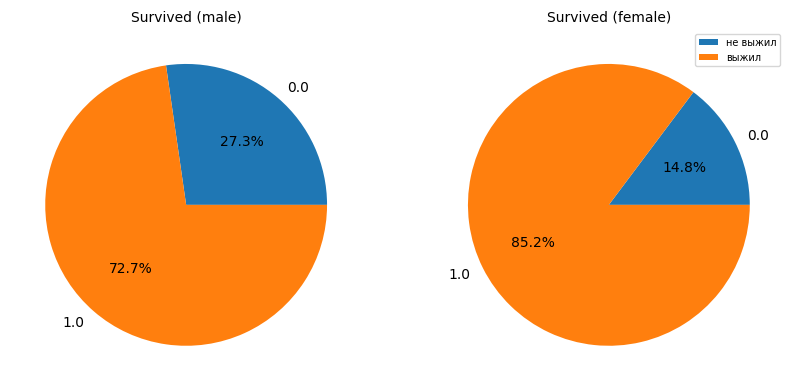

In [56]:
# Тут я поработаю с пока незакодированным дф.
male_isalive = try1_data[try1_data['male'] == 1]['isAlive'].value_counts().sort_values()
female_isalive = try1_data[try1_data['male'] == 0]['isAlive'].value_counts().sort_values()

fig, (ax1, ax2) = plt.pyplot.subplots(1, 2, figsize=(10, 8))

ax1.pie(male_isalive.values, labels=male_isalive.index, autopct='%1.1f%%', textprops={'fontsize': 10})
ax2.pie(female_isalive.values, labels=female_isalive.index, autopct='%1.1f%%', textprops={'fontsize': 10})

ax1.set_title('Survived (male)', fontsize=10)
ax2.set_title('Survived (female)', fontsize=10)

plt.pyplot.legend(['не выжил', 'выжил'], fontsize=7)

# Девочек Мартин убивал чуть реже

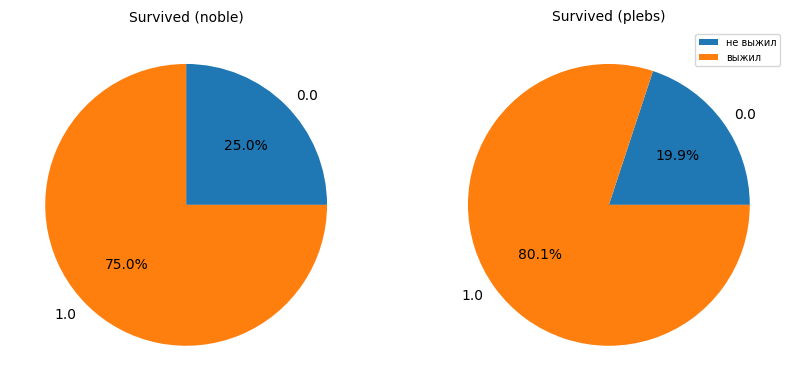

In [57]:
noble_isalive = try1_data[try1_data['isNoble'] == 1]['isAlive'].value_counts().sort_values()
plebs_isalive = try1_data[try1_data['isNoble'] == 0]['isAlive'].value_counts().sort_values()

fig, (ax1, ax2) = plt.pyplot.subplots(1, 2, figsize=(10, 8))

ax1.pie(noble_isalive.values, labels=noble_isalive.index, autopct='%1.1f%%', textprops={'fontsize': 10})
ax2.pie(plebs_isalive.values, labels=plebs_isalive.index, autopct='%1.1f%%', textprops={'fontsize': 10})

ax1.set_title('Survived (noble)', fontsize=10)
ax2.set_title('Survived (plebs)', fontsize=10)

plt.pyplot.legend(['не выжил', 'выжил'], fontsize=7)

#И чуть чаще знать убивал.

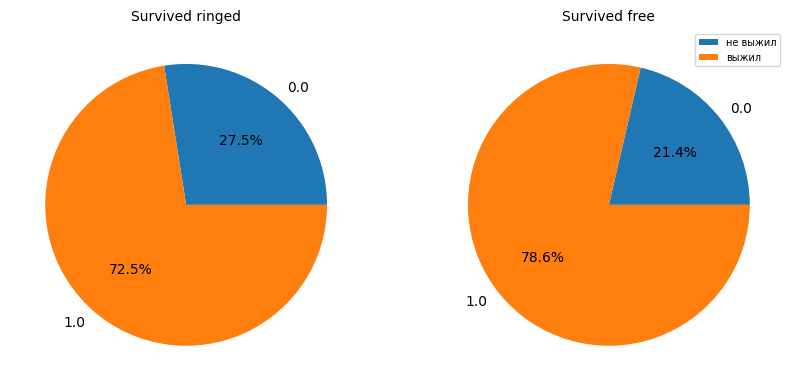

In [58]:
ringed_isalive = try1_data[try1_data['isMarried'] == 1]['isAlive'].value_counts().sort_values()
free_isalive = try1_data[try1_data['isMarried'] == 0]['isAlive'].value_counts().sort_values()

fig, (ax1, ax2) = plt.pyplot.subplots(1, 2, figsize=(10, 8))

ax1.pie(ringed_isalive.values, labels=ringed_isalive.index, autopct='%1.1f%%', textprops={'fontsize': 10})
ax2.pie(free_isalive.values, labels=free_isalive.index, autopct='%1.1f%%', textprops={'fontsize': 10})

ax1.set_title('Survived ringed', fontsize=10)
ax2.set_title('Survived free', fontsize=10)

plt.pyplot.legend(['не выжил', 'выжил'], fontsize=7)

# Женатых и замужних чуть чаще убивал, но это все какие-то крохи.

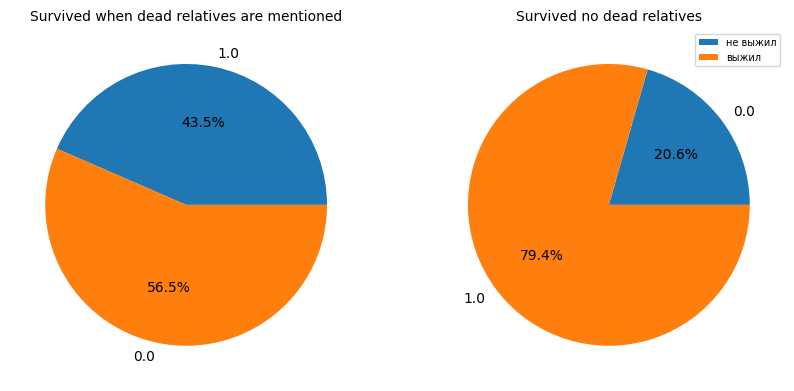

In [59]:
deadRelated_isalive = try1_data[try1_data['boolDeadRelations'] == 1]['isAlive'].value_counts().sort_values()
noDeadRelatives_isalive = try1_data[try1_data['boolDeadRelations'] == 0]['isAlive'].value_counts().sort_values()

fig, (ax1, ax2) = plt.pyplot.subplots(1, 2, figsize=(10, 8))

ax1.pie(deadRelated_isalive.values, labels=deadRelated_isalive.index, autopct='%1.1f%%', textprops={'fontsize': 10})
ax2.pie(noDeadRelatives_isalive.values, labels=noDeadRelatives_isalive.index, autopct='%1.1f%%', textprops={'fontsize': 10})

ax1.set_title('Survived when dead relatives are mentioned', fontsize=10)
ax2.set_title('Survived no dead relatives', fontsize=10)

plt.pyplot.legend(['не выжил', 'выжил'], fontsize=7)

#О, а тут уже серьезная разница. Если твой родственник склеил ласты, стоит напрячься.
# Судя по этим пирожочкам, я думаю над выкидыванием признаков пол, женатость, знатность.
# Но, признаков не так уж и много, да и какая-никакая разница присутствует, пусть останутся.

**Задание 1.9.** Создайте переменные `X`, которая будет хранить только значения признаков, которые вы отобрали для включения в модель, и `y`, которая будет хранить только значения целевой переменной.

In [60]:
# Так, сначала пришло время выделить собственно тестовую часть из объединенного дф, для которой я буду давать ответ на сайте.
# Делаю это по переменной isAlive, с нанами - это строки из исходной тестовой части
# И напомню себе, что Nan != Nan, так что сделать сравнение с Nan нельзя, хорошо, что есть отдельный метод
test_data_processed = try1_onehot_2[try1_onehot_2['isAlive'].isna()]
train_data_processed = try1_onehot_2[try1_onehot_2['isAlive'].notna()]

X = train_data_processed.drop('isAlive', axis=1)
y = train_data_processed['isAlive']

In [61]:
# Проверка
X.head()
# Есть надежда, что умные модели сами переведут булевы Тру\фолз в 1\0. Если нет, то вернусь, поменяю вручную.

,male,book1,book2,book3,book4,book5,isMarried,isNoble,popularity,boolDeadRelations,...,culture_grouped_Old Nations,culture_grouped_Other Nations,culture_grouped_culture_no_data,culture_grouped_the Iron Islands,culture_grouped_the Isles and Rivers,culture_grouped_the Mountain and the Vale,culture_grouped_the North,culture_grouped_the Reach,culture_grouped_the Rock,culture_grouped_the Stormlands
S.No,,,,,,,,,,,,,,,,,,,,,
1,1,0,0,0,0,0,0,0,0.605351,1,...,False,False,True,False,False,False,False,False,False,False
2,1,1,1,1,1,1,1,1,0.896321,1,...,False,False,False,False,True,False,False,False,False,False
3,1,0,0,0,1,0,0,1,0.267559,0,...,False,False,True,False,False,False,False,False,False,False
4,0,0,0,0,0,0,1,1,0.183946,0,...,False,False,True,False,False,False,False,False,False,False
5,0,0,0,0,1,0,1,1,0.043478,0,...,False,False,False,False,False,False,False,False,False,False


**Задание 1.10.** Разделите датасет обучащую и валидационные части (train и val) при помощи функции `train_test_split` (https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)

In [63]:
from sklearn.model_selection import train_test_split

In [64]:
# не забудьте в функции train_test_split задать параметр random_state,
# чтобы обеспечить повторяемость разбиения выборки на train и validation части.
# Это позволит сравнивать метрики моделей с различными методами подготовки признаков
# 20% классика
X_train, X_test, y_train, y_test = train_test_split(X.values, y.values, shuffle=True, test_size=0.2, random_state=42)

## Часть 2. Обучение моделей

В данной части домашнего задания, мы хотим научиться обучать модели для задачи классификации на наших данных.

**Задание 2.1.**


Вы можете работать с одной из предложенных моделей из библиотеки `sklearn`
* LogisticRegression
* RandomForestClassifier
* AdaBoostClassifier
* GaussianProcessClassifier
* GaussianNB
* KNeighborsClassifier
* SVC
* DecisionTreeClassifier


Однако в этом домашнем задании мы предлагаем выбрать и поработать с моделью `LogisticRegression`.

In [65]:
from sklearn.linear_model import LogisticRegression

Импортируйте остальные модели из библиотеки `sklearn`. Чтобы понять как это сделать, воспользуйтесь официальный документацией `sklearn` $→$ [тык](https://scikit-learn.org/dev/user_guide.html). По ключевому названию модели, вы сможете найти необходимую информацию о том, как можно импортировать модель из библиотеки.

**Задание 2.2.** Обучите модель и сделайте предсказание на тестовой выборке

В качестве примера, обучим модель `LogisticRegression` и сделаем на ней предсказания на тестовой выборке.

In [66]:
# Шаг 1. создание модели
model = LogisticRegression(random_state=42, max_iter=1000)

# Шаг 2. обучение модели
model.fit(X_train, y_train)

# Шаг 3. Предсказание на тестовых данных
y_pred = model.predict(X_test)

## Часть 3. Оцените качество моделей

Вам необходимо познакомиться с метриками задачи классификации из sklearn. Оцените все модели и выберите лучшую по метрике качества Accuracy.

С метриками классификации вы можете ознакомиться в [Yandex ML Book](https://education.yandex.ru/handbook/ml/article/metriki-klassifikacii-i-regressii).

Для простоты в данном домашнем задании мы будем работать с самой базовой метрикой для задачи классификации - accuracy.

**Задание 3.1.** Вам необходимо посчитать метрику для всех моделей и выбрать лучшую модель.

Сначала импортируем необходимую функцию из библиотеки sklearn для подсчета accuracy.

In [67]:
from sklearn.metrics import accuracy_score

В качестве примера, посчитаем метрику accuracy для модели `LogisticRegression`

In [68]:
# Шаг 3. Предсказание на тестовых данных

# ваш код здесь

# Шаг 4. Оценка предсказания по метрике accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy : %.4f" % accuracy)

# С первого раза 0.77. Норм.


Accuracy : 0.7724


Возможно, вы решите вернуться на несколько шагов и попробовать другие варианты преобразования и подбора признаков в модель. **Выберите** лучшую модель.

### Тестовый датасет

Поскольку я уже преобразовал и выделил заново тестовый датасет, так что перехожу к предсказанию сразу.
Удалил местные ячейки


In [71]:
# Типа так сработает?
# Путаница у авторов - они выше предложили назвать X_test, y_test, хотя там это были валидационные, и потом авторы поправляются, уже в предсказательной части пишут y_val,
# но я оставил там с суффиксом _test. Просто отмечаю.
y_final_test_pred = model.predict(test_data_processed.drop('isAlive', axis=1))
# Тут выскакивает предупреждение, что модель игнорирует имена колонок. И что она обучалась без них - это trai_test_split сделал массив из дф. А тут я передаю дф.
# По идее, результат не должен отличаться.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [77]:
y_final_test_pred
# Таки да, работает - 66% точности. Такое себе. Но, поскольку я делаю под самый дедлайн (кто у нас солнышко-прокрастинатор), а этот результат на отлично, то едем дальше.

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 0., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 0., 0., 0., 0., 0., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 0., 1., 0., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 0., 1., 1., 0., 0., 1., 1., 1., 1., 1., 0., 0., 1., 0.,
       0., 0., 1., 1., 1., 1., 1., 0., 0., 1., 1., 1., 0., 1., 0., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1.,
       0., 1., 1., 1., 1., 0., 1., 0., 1., 1., 1., 1., 1., 1., 0., 1., 1.,
       1., 1., 1., 1., 0., 1., 0., 1., 0., 0., 1., 1., 1., 1., 0., 1., 1.,
       0., 0., 1., 1., 1., 0., 1., 0., 1., 1., 1., 1., 1., 0., 1., 1., 1.,
       1., 1., 0., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 0., 1.

### Файл `submission.csv`

Вам нужно вместо значений в `submission.csv` файле в колонке `isAlive`, подставить свои предсказания и сохранить измененный файл.

In [74]:
!gdown 1M14conWjAW2QLoyCXbHEAy8bql2f99eF

Downloading...
From: https://drive.google.com/uc?id=1M14conWjAW2QLoyCXbHEAy8bql2f99eF
To: /content/submission.csv
100% 2.74k/2.74k [00:00<00:00, 11.6MB/s]


In [75]:
submission = pd.read_csv("/content/submission.csv", index_col='S.No')

In [76]:
submission

,isAlive
S.No,
1558,0
1559,0
1560,0
1561,0
1562,0
...,...
1942,0
1943,0
1944,0


In [78]:
# Подставляю
submission['isAlive'] = y_final_test_pred


Как сохранить измененный Pandas DataFrame в csv файл:

In [79]:
submission.to_csv("/content/art_HW1_submission.csv", index=False)
